# ROMS / CROCO Output Post-Processing

**Runnable companion to [`roms-model-guide.md`](../roms-model-guide.md) and
[`croco-model-guide.md`](../croco-model-guide.md).**

ROMS and CROCO share the same history-file layout. This notebook opens one and
covers the common ocean post-processing: map sea-surface temperature and the
free surface, and take a vertical temperature section across a strait on the
terrain-following **S-coordinate**.

> The sample file is generated on first run with real ROMS variable names
> (`temp`, `zeta`, `lon_rho`, `lat_rho`, `s_rho`, `ocean_time`). Point
> `xr.open_dataset()` at your own `*_his.nc` to use real output unchanged.
> Domain: Makassar / Lombok Strait (Indonesian Throughflow).

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from meteo_examples import sampledata

HIS = "roms_his_sample.nc"
if not os.path.exists(HIS):
    sampledata.make_roms_history(HIS)

ds = xr.open_dataset(HIS)
plt.rcParams["figure.dpi"] = 110
lon, lat = ds["lon_rho"].values, ds["lat_rho"].values
print("dims:", dict(ds.sizes))
ds

dims: {'ocean_time': 3, 's_rho': 20, 'eta_rho': 90, 'xi_rho': 100}


<xarray.Dataset> Size: 2MB
Dimensions:     (ocean_time: 3, s_rho: 20, eta_rho: 90, xi_rho: 100)
Coordinates:
  * ocean_time  (ocean_time) float64 24B 0.0 8.64e+04 1.728e+05
  * s_rho       (s_rho) float32 80B -0.975 -0.925 -0.875 ... -0.075 -0.025
Dimensions without coordinates: eta_rho, xi_rho
Data variables:
    temp        (ocean_time, s_rho, eta_rho, xi_rho) float32 2MB ...
    zeta        (ocean_time, eta_rho, xi_rho) float32 108kB ...
    lon_rho     (eta_rho, xi_rho) float32 36kB 114.0 114.1 114.1 ... 119.9 120.0
    lat_rho     (eta_rho, xi_rho) float32 36kB -9.0 -9.0 -9.0 ... -3.0 -3.0 -3.0
Attributes:
    title:    SYNTHETIC ROMS history for meteo-notes examples
    type:     ROMS/CROCO history file

## 1 · Sea-surface temperature

Surface = the **last** `s_rho` index (S-coordinate runs from −1 at the bed to 0 at the surface).

SST range: 27.79 – 29.54 °C


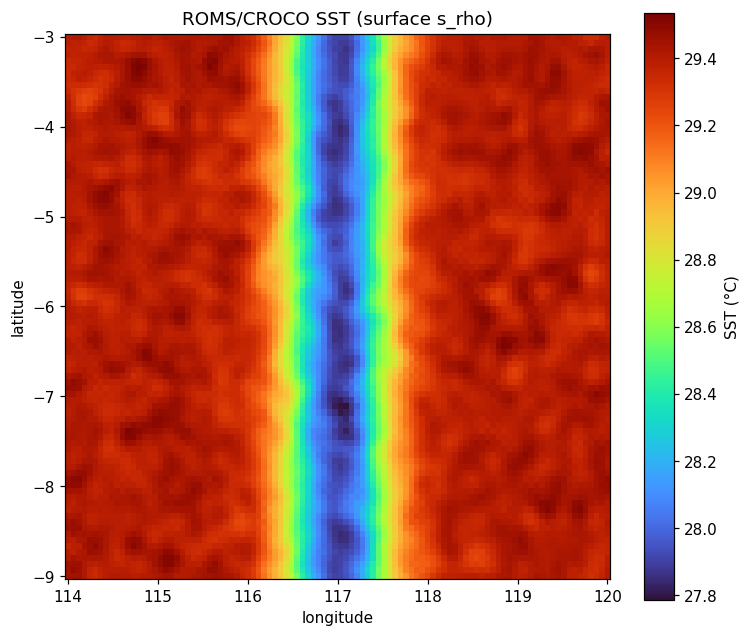

In [2]:
sst = ds["temp"].isel(ocean_time=-1, s_rho=-1).values
fig, ax = plt.subplots(figsize=(7, 6))
pcm = ax.pcolormesh(lon, lat, sst, cmap="turbo", shading="auto")
plt.colorbar(pcm, label="SST (°C)")
ax.set(xlabel="longitude", ylabel="latitude", title="ROMS/CROCO SST (surface s_rho)")
ax.set_aspect("equal"); plt.tight_layout()
print(f"SST range: {sst.min():.2f} – {sst.max():.2f} °C")

## 2 · Free surface (sea-level anomaly)

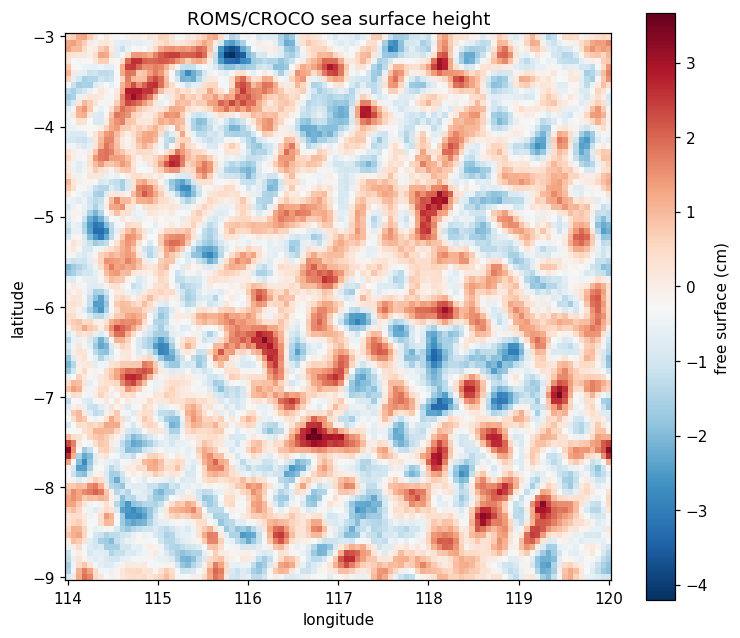

In [3]:
zeta = ds["zeta"].isel(ocean_time=-1).values
fig, ax = plt.subplots(figsize=(7, 6))
pcm = ax.pcolormesh(lon, lat, zeta * 100, cmap="RdBu_r", shading="auto")
plt.colorbar(pcm, label="free surface (cm)")
ax.set(xlabel="longitude", ylabel="latitude", title="ROMS/CROCO sea surface height")
ax.set_aspect("equal"); plt.tight_layout()

## 3 · Vertical temperature section

Take a north–south column of the domain and plot temperature against the
S-coordinate — this is how you inspect the thermocline and throughflow
structure. (On real output, multiply `s_rho` by the local depth to get metres.)

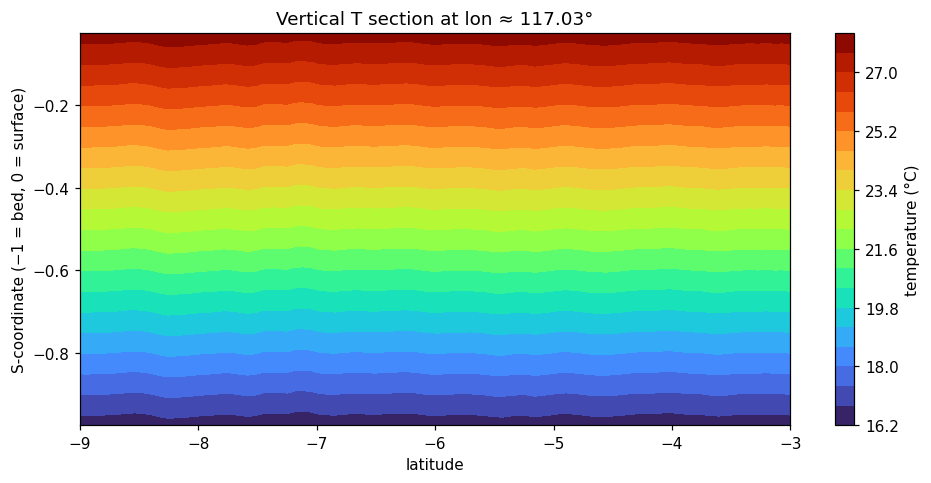

In [4]:
i = lon.shape[1] // 2                      # a mid-domain meridional slice
temp_sec = ds["temp"].isel(ocean_time=-1, xi_rho=i).values   # (s_rho, eta_rho)
y = lat[:, i]
s = ds["s_rho"].values

fig, ax = plt.subplots(figsize=(9, 4.5))
pcm = ax.contourf(y, s, temp_sec, levels=20, cmap="turbo")
plt.colorbar(pcm, label="temperature (°C)")
ax.set(xlabel="latitude", ylabel="S-coordinate (−1 = bed, 0 = surface)",
       title=f"Vertical T section at lon ≈ {lon[0,i]:.2f}°")
plt.tight_layout()

## 4 · Surface-temperature evolution

A simple domain-mean SST time series across the available history records.

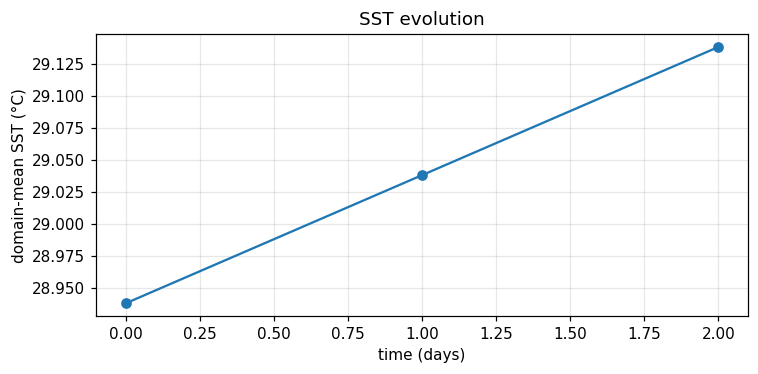

In [5]:
mean_sst = ds["temp"].isel(s_rho=-1).mean(dim=["eta_rho", "xi_rho"]).values
days = ds["ocean_time"].values / 86400.0
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(days, mean_sst, "o-")
ax.set(xlabel="time (days)", ylabel="domain-mean SST (°C)", title="SST evolution")
ax.grid(alpha=0.3); plt.tight_layout()

---
### Apply to your own run
```python
ds = xr.open_dataset("croco_his.nc")   # or roms_his.nc
```
To verify SST against buoys, see
[`../../observations/notebooks/ocean_obs_access.ipynb`](../../observations/notebooks/ocean_obs_access.ipynb)
and `verif.continuous_metrics`. For true depths, reconstruct z from the
S-coordinate stretching (`Cs_r`, `hc`, `h`) as described in the guide.